# ST2195 Coursework Project Part 1 2024/2025
### Name: Glenda Ho            
### Student ID:230572931
### Part 1 Python

## Question 1a) 

#### For part 1a), the objective is to work with the Metropolis-Hastings algorithm to generate random numbers following the given probability density function and evaluate the quality of the sample by comparing its mean and standard deviation.

The import of **"numpy"** allows us to numerical functions in python.
<br>
<br>
The import of **"matplotlib.pyplot"** allows us to plot graphs.
<br>
<br>
The import of **"seaborn"** allows us to create complex visualisations.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Define the probability density function(PDF) using the provided equation. Using **"f(x)"** to calculate the PDF for a particular value **"x"**, returning the PDF's value at that particular **"x"** value. Using **"np.exp"** to calculate the exponential of the input value, and using **"abs"** to ensure that the value of **"x"** is always positive regardless of the sign.

In [6]:
def f(x):
    return 0.5 * np.exp(-abs(x))

Define the parameters as such: **"N"** representing the number of samples, given at 10000.**"Xo"** representing the initial value and **"s"** representing the standard deviation, given at 1. 

In [8]:
N = 10000
s = 1
Xo = 0 

Implement the "Metropolis-Hastings algorithm" to generate samples from the targeted distribution, using the parameters defined earlier (N,Xo,s)
<br>
**"samples = [Xo]"** helps to initialise a list called samples with the initial value **"Xo"**
<br>
<br>
Setting up a for loop, that repeats for 1 to "N"(10000) times.
<br>
<br>
Within the loop, **"Xprev = samples[-1]"** is used to retrieve the most recent sample from the list of samples. <br>**"Xstar = np.random.normal(loc=Xprev, scale=s)"** is used to generate a new sample from a normal distribution centred(**"loc"**) at Xprev and, with a standard deviation(**"scale"**) of s.
<br>
<br>
Within the loop, **"log_r = np.log(f(Xstar)) - np.log(f(Xprev))"** is used to compute the acceptance ratio between the proposed sample(**"Xstar"**) and the most recent sample(**"Xprev"**). The question provides the log formula to avoid numerical errors.
<br>
<br>
Within the loop, **"u = np.random.uniform(0, 1)"** is used to generate a random number u from the uniform distribution between 0 and 1.
<br><br>
Within the loop, we created a **"if"** statement that checks if the ratio(**"log_r"**) is greater than the random number u(**"np.log(u)"**). If it is,**"samples.append(x_star)"** adds the newly accepted sample to the list of generated samples. Otherwise, the **"else"** statement(**"samples.append(x_prev)"**) adds the previous sample back into the list again. 
<br><br>
Lastly, the function **"return"** returns the array of samples generated.

In [10]:
def metropolis_hastings(Xo, N, s):
    samples = [Xo]
    for i in range(1, N):
        Xprev = samples[-1]
        Xstar = np.random.normal(loc=Xprev, scale=s)
        
        log_r = np.log(f(Xstar)) - np.log(f(Xprev))
        
        u = np.random.uniform(0, 1)
        
        if np.log(u) < log_r:
            samples.append(Xstar)
        else:
            samples.append(Xprev)
    return np.array(samples)

Using the metropolis_hastings to generate a sample with the provided parameter.

In [12]:
samples = metropolis_hastings(Xo, N, s)

Creating a histogram and kernel density estimate(in blue) and plot the probability density distribution f(x)(in red) for comparison. This visual comparison allows you to see how well the samples approximate the target distribution. 

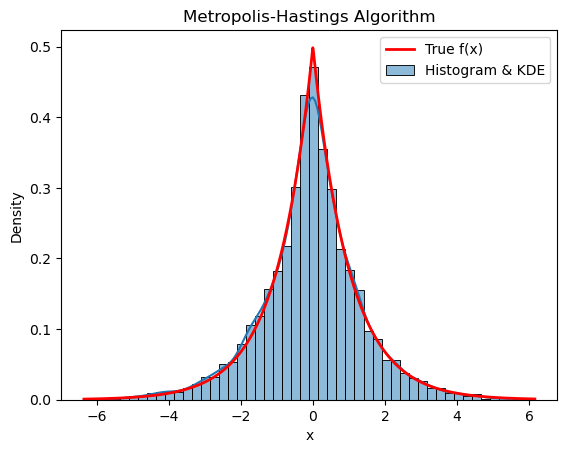

In [14]:
sns.histplot(samples, bins=50, kde=True, stat="density", label="Histogram & KDE")
x_vals = np.linspace(min(samples), max(samples), 1000)
plt.plot(x_vals, f(x_vals), color='red', label='True f(x)', linewidth=2)

plt.title('Metropolis-Hastings Algorithm')
plt.xlabel('x')
plt.legend()
plt.show()

Print the Monte Carlo Estimate of Mean and Standard Deviation.

In [16]:
mean_estimate = np.mean(samples)
std_estimate = np.std(samples)
print(f"Monte Carlo Estimate of Mean: {mean_estimate}")
print(f"Monte Carlo Estimate of Standard Deviation: {std_estimate}")


Monte Carlo Estimate of Mean: -0.03695433548460639
Monte Carlo Estimate of Standard Deviation: 1.388935418219148


## Question 1b)

#### For Question 1b, the objective is to assess the convergence of the Metropolis-Hastings algorithm by computing the R_values(R hat) using specified parameters while varying the standard deviation (s) within a given range.


Define the parameters as such:**"N1"** represents the number of samples per chain, given at 2000. **"Xob"** represents the initial values for each chain, at -15,0,15,40.

In [19]:
N1 = 2000
Xob = np.array([-15, 0, 15, 40])

**"s_values = np.arange(0.001, 1.001, 0.001)"** creates an array of s values starting from 0.001 up to 1.000, with increments of 0.001.

**"R_values = np.zeros(len(s_values))"** initializes an array of zeros with the same length as s_values.

In [21]:
s_values = np.arange(0.001, 1.001, 0.001)
R_values = np.zeros(len(s_values))

Creating an outer loop that iterates over the Xob list and for each element Xo, it runs the Metropolis-Hastings algorithm to generate a set of samples (**"samplesb"**).

In [23]:
for J, Xo in enumerate(Xob, start=1):
    
    samplesb = metropolis_hastings(Xo, N1, s_values[0])  
    
    globals()[f'sample{J}'] = samplesb

Setting up a for loop to calculate the R value for each step size value **"s"** in the array **"s_values"**, and iterating over each step size with the code within the loop.<br><br>
Within the loop, **"means = np.zeros(len(Xob))"** and **"vars = np.zeros(len(Xob))"** to initialise arrays for the mean and variance for each chain.<br><br>
Within the loop, create an inner for loop to computes the mean and variance of the generated samples and store them in the means and vars arrays at the corresponding index J.<br><br>
Within the loop,<br> -**" M = np.mean(means)"** calculate the overall mean.<br> -**"W = np.mean(vars)"** calculate the overall within sample variance.<br>
-__"B = np.sum((means - M)*2) / len(Xob)"__ calculate the between sample variance. <br> -**"w_in = np.mean(vars)"** calculates the within sample variance.<br> -**" R = np.sqrt((B + w_in) / w_in)"** calculate the r hat value and **"R_values[s_index] = R"** store the R value in an array for the current step size.

In [25]:
for s_index, s in enumerate(s_values):
    means = np.zeros(len(Xob))
    vars = np.zeros(len(Xob))

    for J, Xob_value in enumerate(Xob):
        samplesb = metropolis_hastings(Xob_value, N1, s)
        means[J] = np.mean(samplesb)
        vars[J] = np.var(samplesb)

    M = np.mean(means)
    W = np.mean(vars)

    B = np.sum((means - M)**2) / len(Xob)

    w_in = np.mean(vars)

    R = np.sqrt((B + w_in) / w_in)

    R_values[s_index] = R

We plot the **"R_values"** against the step size value **"s_values"**. The blue line represents the R values while the red dashed line indicates the threshold value of 1.05.


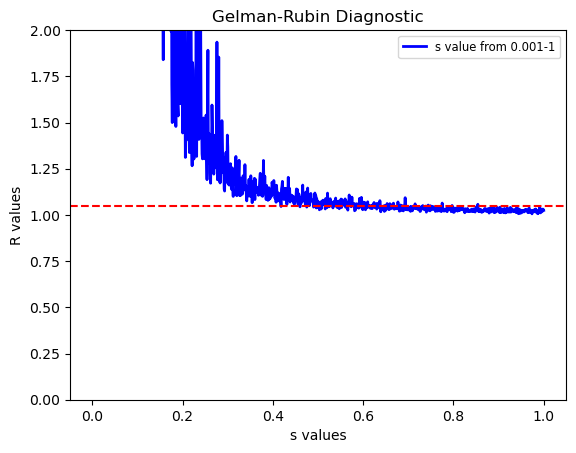

In [27]:
plt.plot(s_values, R_values, color="blue", linewidth=2)
plt.axhline(y=1.05, color="red", linestyle="--")

plt.xlabel("s values")
plt.ylabel("R values")
plt.title("Gelman-Rubin Diagnostic")

plt.legend(["s value from 0.001-1"], loc="upper right", fontsize="small")

plt.ylim(0, 2)

plt.show()

Print the "R"(R hat) value; value lower than 1.05 is desirable.

In [29]:
print("R hat value:", (R))

R hat value: 1.0249671295970095
